In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the Titanic dataset
titanic_data = pd.read_csv('titanic.csv')
# Display the first few rows of the dataset
print(titanic_data.head())

   PassengerId  Survived  Pclass      Lname  \
0            1         0       3     Braund   
1            2         1       1    Cumings   
2            3         1       3  Heikkinen   
3            4         1       1   Futrelle   
4            5         0       3      Allen   

                                          Name     Sex   Age  SibSp  Parch  \
0                              Mr. Owen Harris    male  22.0      1      0   
1   Mrs. John Bradley (Florence Briggs Thayer)  female  38.0      1      0   
2                                  Miss. Laina  female  26.0      0      0   
3           Mrs. Jacques Heath (Lily May Peel)  female  35.0      1      0   
4                            Mr. William Henry    male  35.0      0      0   

             Ticket     Fare Cabin Embarked  
0         A/5 21171   7.2500   NaN        S  
1          PC 17599  71.2833   C85        C  
2  STON/O2. 3101282   7.9250   NaN        S  
3            113803  53.1000  C123        S  
4            37345

In [4]:
# Summary of the dataset
print("\nDataset Information:")
print(titanic_data.info())

# Check for missing values
print("\nMissing values in each column:")
print(titanic_data.isnull().sum())

# Statistical summary
print("\nStatistical Summary:")
print(titanic_data.describe())



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  156 non-null    int64  
 1   Survived     156 non-null    int64  
 2   Pclass       156 non-null    int64  
 3   Lname        156 non-null    object 
 4   Name         156 non-null    object 
 5   Sex          156 non-null    object 
 6   Age          126 non-null    float64
 7   SibSp        156 non-null    int64  
 8   Parch        156 non-null    int64  
 9   Ticket       156 non-null    object 
 10  Fare         156 non-null    float64
 11  Cabin        31 non-null     object 
 12  Embarked     155 non-null    object 
dtypes: float64(2), int64(5), object(6)
memory usage: 16.0+ KB
None

Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Lname            0
Name             0
Sex              0
Age             30
SibSp     

In [5]:
# Check unique values for categorical columns
print(titanic_data['Sex'].unique())
print(titanic_data['Embarked'].unique())
print(titanic_data['Pclass'].unique())

['male' 'female']
['S' 'C' 'Q' nan]
[3 1 2]


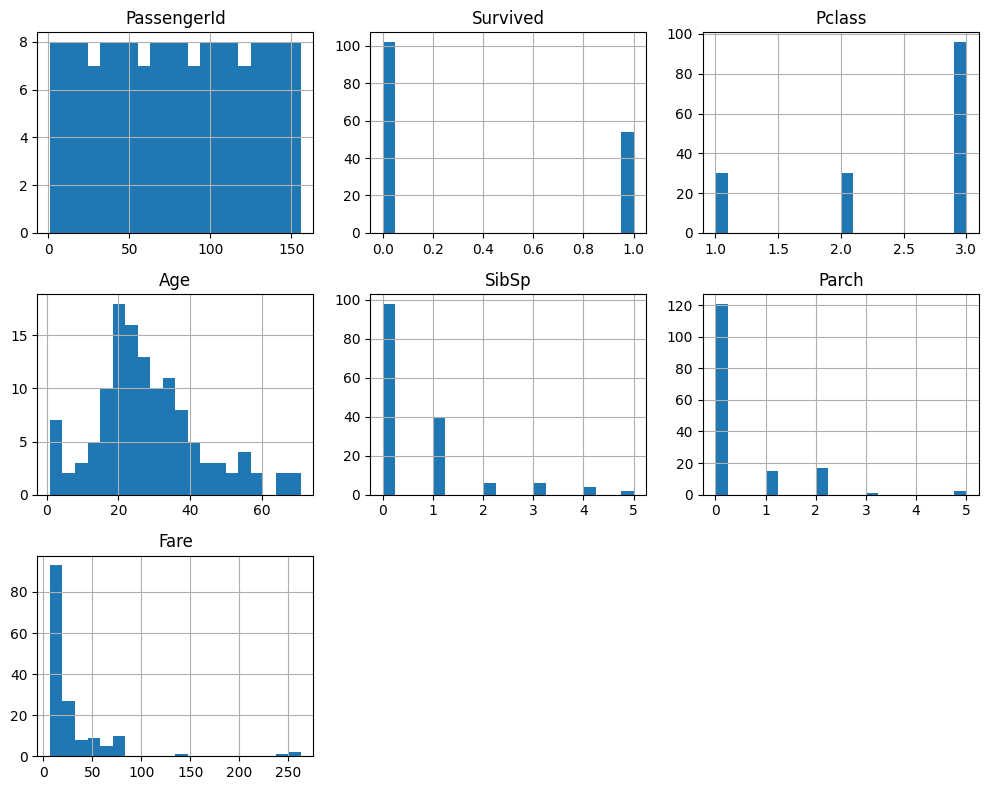

In [6]:
# Plot histogram for numerical columns
titanic_data.hist(bins=20, figsize=(10, 8))
plt.tight_layout()
plt.show()

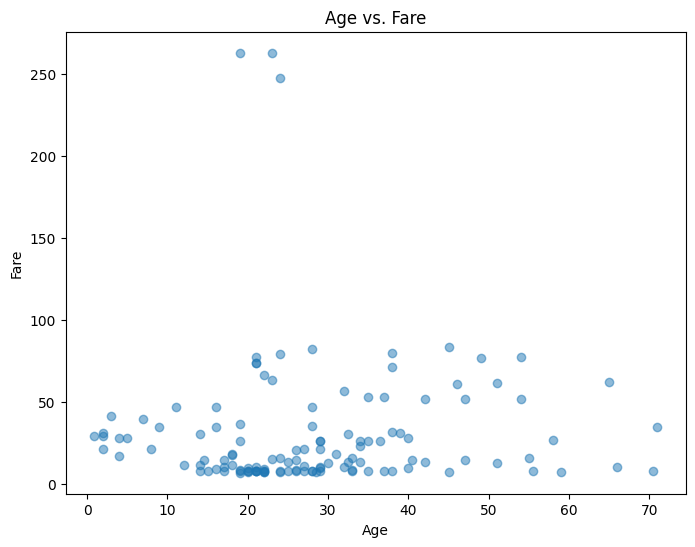

In [7]:
# Scatter plot to visualize Age vs. Fare
plt.figure(figsize=(8,6))
plt.scatter(titanic_data['Age'], titanic_data['Fare'], alpha=0.5)
plt.title('Age vs. Fare')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

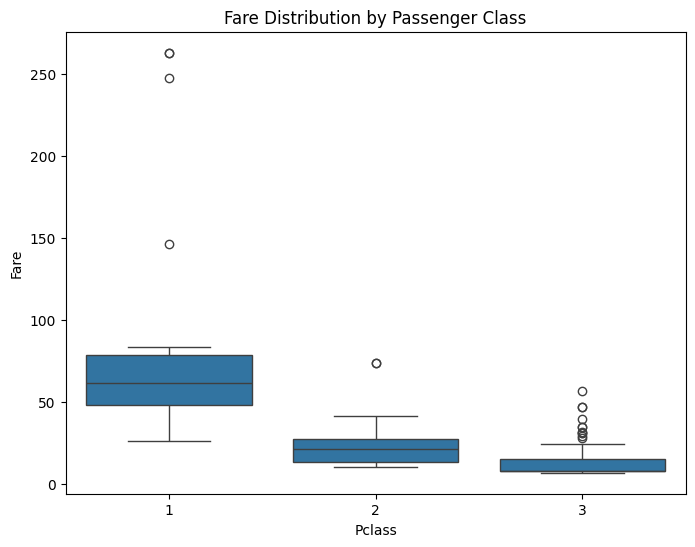

In [8]:
# Boxplot to compare fare by class
plt.figure(figsize=(8,6))
sns.boxplot(x='Pclass', y='Fare', data=titanic_data)
plt.title('Fare Distribution by Passenger Class')
plt.show()


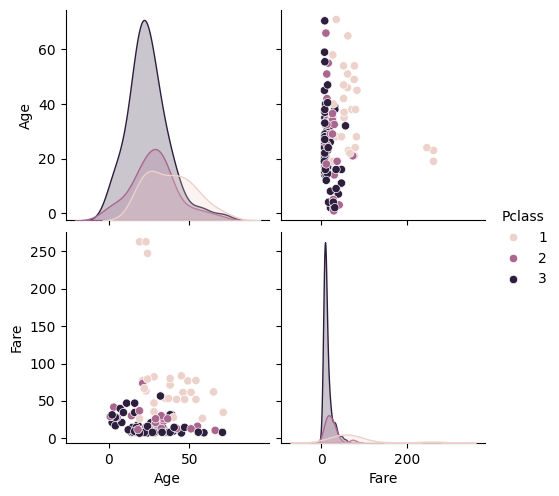

In [9]:
# Pair plot for continuous variables
sns.pairplot(titanic_data[['Age', 'Fare', 'Pclass']], hue='Pclass', diag_kind='kde')
plt.show()


In [10]:
# Creating a new feature 'FamilySize'
titanic_data['FamilySize'] = titanic_data['SibSp'] + titanic_data['Parch'] + 1
# Check the first few rows to confirm the new feature
print(titanic_data[['SibSp', 'Parch', 'FamilySize']].head())


   SibSp  Parch  FamilySize
0      1      0           2
1      1      0           2
2      0      0           1
3      1      0           2
4      0      0           1


In [12]:
# Extracting title from names
titanic_data['Title'] = titanic_data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Check for unique titles
print(titanic_data['Title'].unique())


['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev']


<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
C:\Users\student\AppData\Local\Temp\ipykernel_2528\3185880616.py:2: SyntaxWarning: invalid escape sequence '\.'
  titanic_data['Title'] = titanic_data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [13]:
# Fill missing values in 'Age' with the median age
titanic_data['Age'].fillna(titanic_data['Age'].median(), inplace=True)

# Fill missing values in 'Embarked' with the most common port
titanic_data['Embarked'].fillna(titanic_data['Embarked'].mode()[0], inplace=True)

# Drop the 'Cabin' column since it has too many missing values
titanic_data.drop(columns=['Cabin'], inplace=True)

# Confirm that missing values have been addressed
print("\nMissing values after cleaning:")
print(titanic_data.isnull().sum())



Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Lname          0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
FamilySize     0
Title          0
dtype: int64


C:\Users\student\AppData\Local\Temp\ipykernel_2528\1291398176.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_data['Age'].fillna(titanic_data['Age'].median(), inplace=True)
C:\Users\student\AppData\Local\Temp\ipykernel_2528\1291398176.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

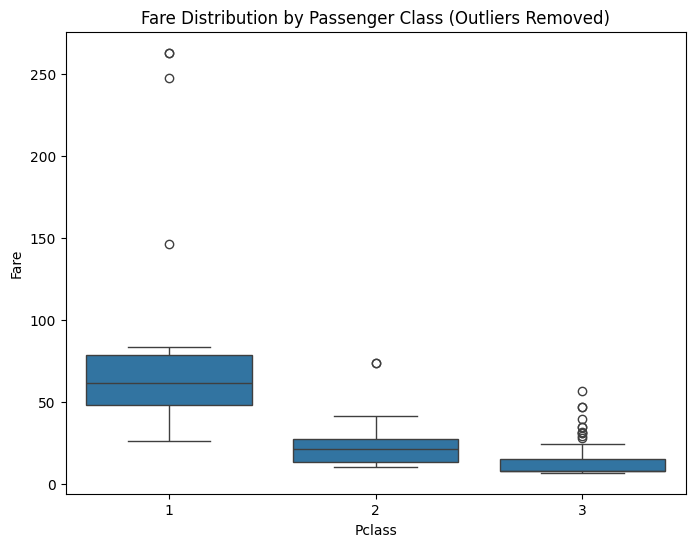

In [14]:
# Remove outliers in 'Fare'
titanic_data = titanic_data[titanic_data['Fare'] < 300]

# Plot the updated boxplot for Fare by Passenger Class
plt.figure(figsize=(8,6))
sns.boxplot(x='Pclass', y='Fare', data=titanic_data)
plt.title('Fare Distribution by Passenger Class (Outliers Removed)')
plt.show()


In [15]:
# Save the cleaned dataset to a new CSV file
titanic_data.to_csv('titanic_cleaned.csv', index=False)

print("Cleaned dataset saved as 'titanic_cleaned.csv'")


Cleaned dataset saved as 'titanic_cleaned.csv'


In [16]:
titanic_cleaned = pd.read_csv('titanic_cleaned.csv')
titanic_cleaned.head()


,PassengerId,Survived,Pclass,Lname,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,Title
0,1,0,3,Braund,Mr. Owen Harris,male,22.0,1,0,A/5 21171,7.2500,S,2,Mr
1,2,1,1,Cumings,Mrs. John Bradley (Florence Briggs Thayer),female,38.0,1,0,PC 17599,71.2833,C,2,Mrs
2,3,1,3,Heikkinen,Miss. Laina,female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,Miss
3,4,1,1,Futrelle,Mrs. Jacques Heath (Lily May Peel),female,35.0,1,0,113803,53.1000,S,2,Mrs
4,5,0,3,Allen,Mr. William Henry,male,35.0,0,0,373450,8.0500,S,1,Mr


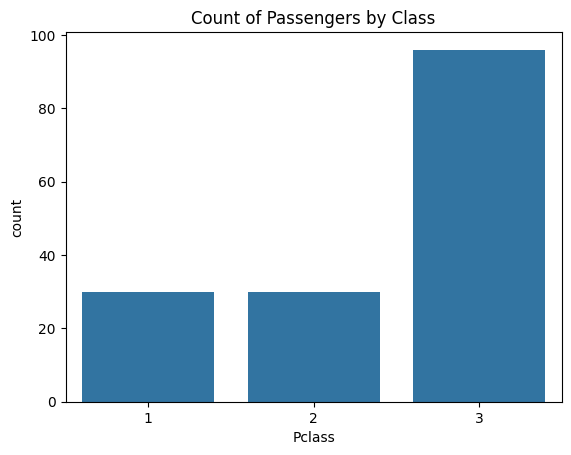

In [17]:
# Countplot for Pclass
sns.countplot(x='Pclass', data=titanic_cleaned)
plt.title('Count of Passengers by Class')
plt.show()


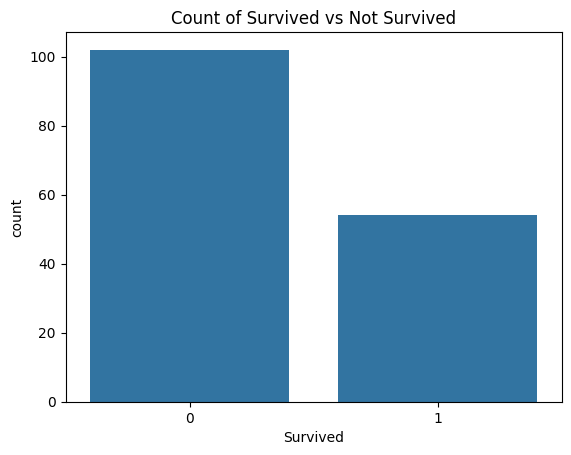

In [18]:
# Countplot for Survived
sns.countplot(x='Survived', data=titanic_data)
plt.title('Count of Survived vs Not Survived')
plt.show()


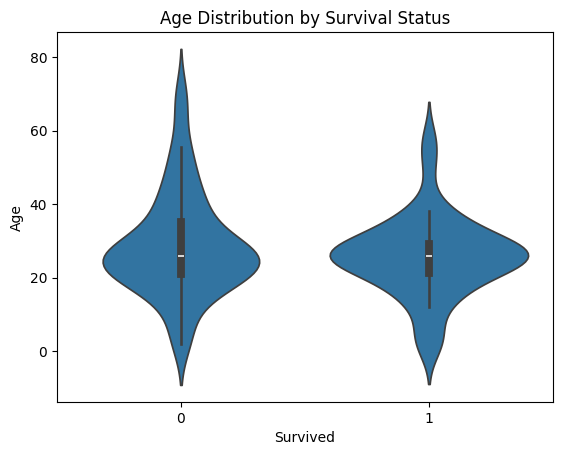

In [19]:
# Violin plot for Age distribution by survival status
sns.violinplot(x='Survived', y='Age', data=titanic_cleaned)
plt.title('Age Distribution by Survival Status')
plt.show()
